# 🤖 Demo: Entrenamiento de un Modelo de IA con Datos Validados
## Actividad 3.1 – Diseño, entrenamiento y evaluación inicial

**Problemática:** clasificación supervisada sobre el CSV validado generado por el ETL de ventas.

**Objetivo:** recorrer el flujo completo de un modelo supervisado con scikit-learn:
1. Cargar el dataset validado desde archivo
2. Explorar los datos
3. Definir una variable objetivo útil para la demo
4. Dividir datos en entrenamiento y prueba
5. Construir y entrenar el modelo
6. Evaluar con métricas
7. Comparar algoritmos

---

## Instalar dependencias

Si el entorno no tiene las librerías necesarias, ejecuta una vez:

```bash
pip install pandas numpy matplotlib scikit-learn
```

## 📦 Paso 0: Importar librerías

In [2]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
## 📂 Paso 1: Cargar el CSV validado

Vamos a usar el archivo `data/processed/ventas_validas.csv`, generado por el ETL luego de limpiar y validar las ventas de la tienda.

| Variable | Descripción | Tipo |
|---|---|---|
| `id` | Identificador del registro | Numérica |
| `fecha` | Fecha de la venta | Fecha |
| `producto` | Producto vendido | Categórica |
| `cantidad` | Unidades vendidas | Numérica |
| `precio` | Precio unitario | Numérica |
| `ciudad` | Ciudad de la venta | Categórica |
| `total` | Monto total de la venta | Numérica |
| `estado_calidad` | Estado del registro | Categórica |
| `fuente` | Origen del registro | Categórica |

> **Variable objetivo de esta demo:** crear una clasificación binaria de `venta_alta`, donde `1` identifica tickets con mayor valor comercial para priorizar stock, promociones y reposición.

In [3]:
ruta_csv = Path('data/processed/ventas_validas.csv')
df = pd.read_csv(ruta_csv)
df['fecha'] = pd.to_datetime(df['fecha'], errors='coerce')

print('✅ Dataset validado cargado correctamente')
print(f'   {df.shape[0]} registros  |  {df.shape[1]} columnas')
print()
df.head(10)

✅ Dataset validado cargado correctamente
   500 registros  |  17 columnas



,id,fecha,producto,cantidad,precio,ciudad,total,valid_fecha,valid_cantidad,valid_precio,valid_producto,valid_ciudad,valid_total,es_valido,motivo_invalidacion,estado_calidad,fuente
0,236,2026-04-06,Flores THC 10%,8.0,77796.0,Santiago,622368.0,True,True,True,True,True,True,True,NaN,clean,transformacion
1,390,2026-04-07,Aceite CBD 5%,3.0,32109.0,Concepción,96327.0,True,True,True,True,True,True,True,NaN,clean,transformacion
2,160,2026-01-05,Flores THC 10%,4.0,32017.0,Concepción,128068.0,True,True,True,True,True,True,True,NaN,clean,transformacion
3,453,2026-04-07,Cápsulas CBN,4.0,22291.0,Santiago,89164.0,True,True,True,True,True,True,True,NaN,clean,transformacion
4,175,2026-03-13,Aceite CBD 5%,1.0,59130.0,Santiago,59130.0,True,True,True,True,True,True,True,NaN,clean,transformacion
5,439,2026-03-26,Flores THC 10%,3.0,58178.0,Santiago,174534.0,True,True,True,True,True,True,True,NaN,clean,transformacion
6,119,2026-02-08,Cápsulas CBN,9.0,15156.0,Viña del Mar,136404.0,True,True,True,True,True,True,True,NaN,clean,transformacion
7,454,2026-01-09,Flores THC 10%,2.0,42590.0,Concepción,85180.0,True,True,True,True,True,True,True,NaN,clean,transformacion
8,339,2026-02-09,Cápsulas CBN,5.0,77255.0,Concepción,386275.0,True,True,True,True,True,True,True,NaN,clean,transformacion
9,244,2026-03-03,Aceite CBD 5%,4.0,26234.0,Santiago,104936.0,True,True,True,True,True,True,True,NaN,clean,transformacion


---
## 🔍 Paso 2: Explorar el Dataset

📋 Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   id                   500 non-null    int64         
 1   fecha                500 non-null    datetime64[ns]
 2   producto             500 non-null    object        
 3   cantidad             500 non-null    float64       
 4   precio               500 non-null    float64       
 5   ciudad               500 non-null    object        
 6   total                500 non-null    float64       
 7   valid_fecha          500 non-null    bool          
 8   valid_cantidad       500 non-null    bool          
 9   valid_precio         500 non-null    bool          
 10  valid_producto       500 non-null    bool          
 11  valid_ciudad         500 non-null    bool          
 12  valid_total          500 non-null    bool          
 13  es_valido   

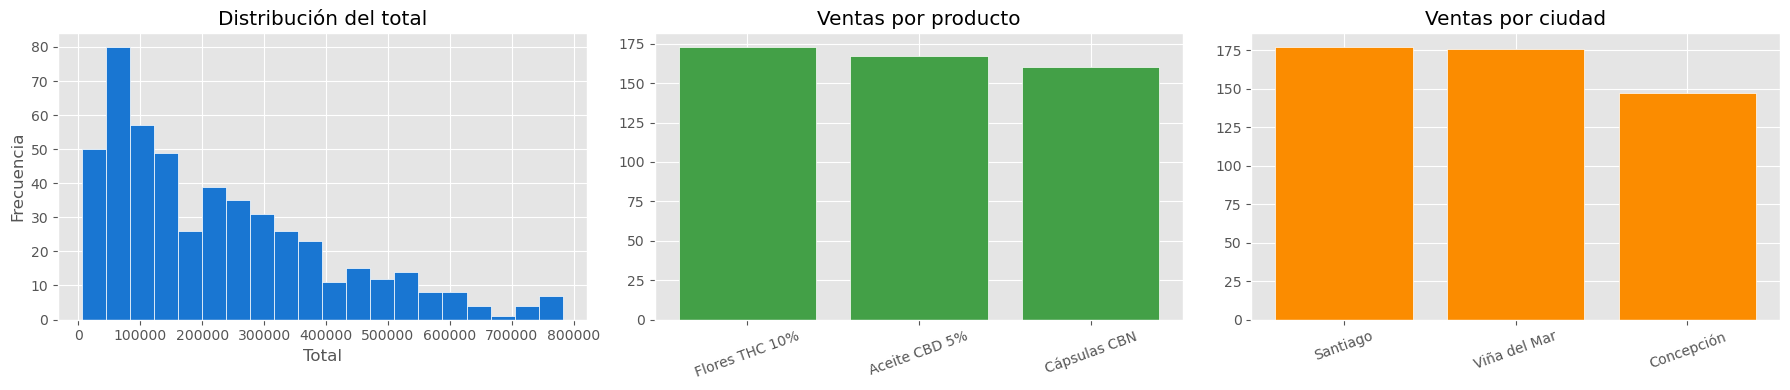

In [4]:
print('📋 Información general:')
df.info()
print()

print('📊 Estadísticas descriptivas:')
print(df[['cantidad', 'precio', 'total']].describe().round(2))
print()

print('🔎 Valores nulos por columna:')
print(df.isnull().sum())
print()

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(df['total'], bins=20, color='#1976D2', edgecolor='white')
axes[0].set_title('Distribución del total')
axes[0].set_xlabel('Total')
axes[0].set_ylabel('Frecuencia')

producto_counts = df['producto'].value_counts()
axes[1].bar(producto_counts.index, producto_counts.values, color='#43A047', edgecolor='white')
axes[1].set_title('Ventas por producto')
axes[1].tick_params(axis='x', rotation=20)

ciudad_counts = df['ciudad'].value_counts()
axes[2].bar(ciudad_counts.index, ciudad_counts.values, color='#FB8C00', edgecolor='white')
axes[2].set_title('Ventas por ciudad')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

🎯 Variable objetivo creada: venta_alta
   Umbral usado: total >= 183023.50

   Ventas bajas (0): 250 registros (50.0%)
   Ventas altas (1): 250 registros (50.0%)


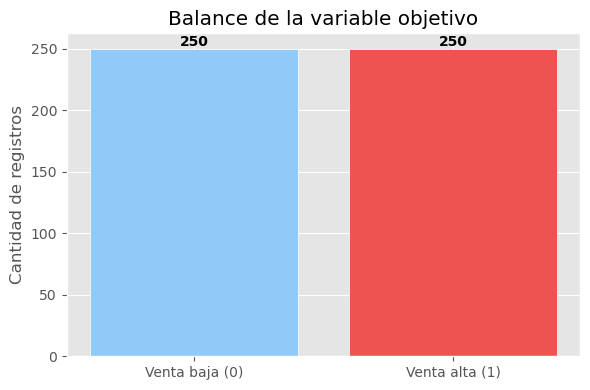

In [5]:
umbral_venta_alta = df['total'].median()
df['venta_alta'] = (df['total'] >= umbral_venta_alta).astype(int)
df['mes'] = df['fecha'].dt.month.astype('Int64')
df['dia_semana'] = df['fecha'].dt.day_name()
df['es_fin_de_semana'] = df['fecha'].dt.dayofweek.isin([5, 6]).astype(int)

print('🎯 Variable objetivo creada: venta_alta')
print(f'   Umbral usado: total >= {umbral_venta_alta:.2f}')
print()
conteo = df['venta_alta'].value_counts().sort_index()
pct = df['venta_alta'].value_counts(normalize=True).sort_index() * 100
print(f'   Ventas bajas (0): {conteo.get(0, 0)} registros ({pct.get(0, 0):.1f}%)')
print(f'   Ventas altas (1): {conteo.get(1, 0)} registros ({pct.get(1, 0):.1f}%)')

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Venta baja (0)', 'Venta alta (1)'], conteo.values, color=['#90CAF9', '#EF5350'], edgecolor='white')
ax.set_title('Balance de la variable objetivo')
ax.set_ylabel('Cantidad de registros')
for i, value in enumerate(conteo.values):
    ax.text(i, value + 2, str(value), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🎯 Paso 3: Definir la variable objetivo

Como el CSV validado no trae una etiqueta de negocio lista para clasificar, crearemos una variable derivada que represente tickets con mayor valor para la tienda:

- `venta_alta = 1` si `total` está por encima o igual a la mediana
- `venta_alta = 0` si `total` está por debajo de la mediana

Esto nos permite hacer una demo de clasificación supervisada realista con scikit-learn y conectar el resultado con decisiones de inventario, campañas y ventas.

In [6]:
feature_columns = ['cantidad', 'precio', 'producto', 'ciudad', 'mes', 'dia_semana', 'es_fin_de_semana']
X = df[feature_columns].copy()
y = df['venta_alta'].copy()

print('✅ Variables seleccionadas:')
print(f'   X columnas: {feature_columns}')
print(f'   X shape: {X.shape}')
print(f'   y shape: {y.shape}')
print()
print(f'   Proporción de venta_alta=1: {y.mean()*100:.1f}%')

✅ Variables seleccionadas:
   X columnas: ['cantidad', 'precio', 'producto', 'ciudad', 'mes', 'dia_semana', 'es_fin_de_semana']
   X shape: (500, 7)
   y shape: (500,)

   Proporción de venta_alta=1: 50.0%


---
## ✂️ Paso 4: Dividir en Entrenamiento y Prueba

Proporción: **80% entrenamiento / 20% prueba**  
Con `stratify=y` garantizamos que ambos conjuntos tengan proporción similar de ventas altas.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print('✅ División completada:')
print(f'   Total de registros : {len(df)}')
print(f'   Entrenamiento      : {len(X_train)} registros ({len(X_train)/len(df)*100:.0f}%)')
print(f'   Prueba             : {len(X_test)} registros ({len(X_test)/len(df)*100:.0f}%)')
print()
print('🔎 Balance de clases por conjunto:')
print(f'   Entrenamiento → Venta alta: {y_train.mean()*100:.1f}%')
print(f'   Prueba        → Venta alta: {y_test.mean()*100:.1f}%')

✅ División completada:
   Total de registros : 500
   Entrenamiento      : 400 registros (80%)
   Prueba             : 100 registros (20%)

🔎 Balance de clases por conjunto:
   Entrenamiento → Venta alta: 50.0%
   Prueba        → Venta alta: 50.0%


---
## 🏗️ Paso 5: Construir el modelo

Usaremos varios algoritmos de scikit-learn para comparar su desempeño sobre variables que sí conoce el negocio:

- Regresión Logística
- Árbol de Decisión
- Random Forest

Primero entrenaremos una línea base y luego compararemos resultados para ver qué opción ayuda mejor a anticipar ventas de mayor valor.

In [8]:
numericas = ['cantidad', 'precio']
categoricas = ['producto', 'ciudad', 'mes', 'dia_semana', 'es_fin_de_semana']

preprocesamiento = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler()),
        ]), numericas),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), categoricas),
    ]
)

modelos = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
}

pipelines = {
    nombre: Pipeline([
        ('preprocesamiento', preprocesamiento),
        ('modelo', estimador),
    ])
    for nombre, estimador in modelos.items()
}

print('✅ Modelos configurados:')
for nombre in pipelines:
    print(f'   - {nombre}')

✅ Modelos configurados:
   - Regresión Logística
   - Árbol de Decisión
   - Random Forest


In [9]:
resultados = []
predicciones = {}

for nombre, pipeline in pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred_modelo = pipeline.predict(X_test)
    predicciones[nombre] = y_pred_modelo
    resultados.append({
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred_modelo),
        'Precision': precision_score(y_test, y_pred_modelo, zero_division=0),
        'Recall': recall_score(y_test, y_pred_modelo, zero_division=0),
        'F1-Score': f1_score(y_test, y_pred_modelo, zero_division=0),
    })

resultados_df = pd.DataFrame(resultados).sort_values('F1-Score', ascending=False)
mejor_modelo = resultados_df.iloc[0]['Modelo']

print('✅ Modelos entrenados correctamente')
print()
print('📐 Resumen de métricas de entrenamiento:')
print(resultados_df.to_string(index=False))
print()
print(f'🏆 Mejor modelo según F1-Score: {mejor_modelo}')

✅ Modelos entrenados correctamente

📐 Resumen de métricas de entrenamiento:
             Modelo  Accuracy  Precision  Recall  F1-Score
  Árbol de Decisión      0.99   0.980392    1.00  0.990099
Regresión Logística      0.97   0.943396    1.00  0.970874
      Random Forest      0.94   0.958333    0.92  0.938776

🏆 Mejor modelo según F1-Score: Árbol de Decisión


---
## 📏 Paso 7: Evaluar el Modelo

Usamos el conjunto de **prueba** (datos que el modelo nunca vio) para medir su desempeño real y estimar si puede apoyar decisiones comerciales.

In [16]:
modelo_evaluado = pipelines['Regresión Logística']
y_pred = modelo_evaluado.predict(X_test)

accuracy  = accuracy_score(y_test, y_pred)  # compara todo
precision = precision_score(y_test, y_pred, zero_division=0) # compara los que predijo como positivos
recall    = recall_score(y_test, y_pred, zero_division=0)    # compara los positivos reales
f1        = f1_score(y_test, y_pred, zero_division=0)        # combina precision y recall

print('📊 MÉTRICAS DE EVALUACIÓN')
print('=' * 40)
print(f'  Accuracy  (Exactitud) : {accuracy*100:.1f}%')
print(f'  Precision             : {precision*100:.1f}%')
print(f'  Recall (Sensibilidad) : {recall*100:.1f}%')
print(f'  F1-Score              : {f1*100:.1f}%')
print('=' * 40)
print()
print('🔎 Interpretación:')
print(f'  De cada 100 registros, el modelo acierta {accuracy*100:.0f}')
print(f'  De las ventas altas reales, detecta el {recall*100:.0f}%')
print(f'  Cuando predice venta alta, acierta el {precision*100:.0f}% de las veces')

📊 MÉTRICAS DE EVALUACIÓN
  Accuracy  (Exactitud) : 97.0%
  Precision             : 94.3%
  Recall (Sensibilidad) : 100.0%
  F1-Score              : 97.1%

🔎 Interpretación:
  De cada 100 registros, el modelo acierta 97
  De las ventas altas reales, detecta el 100%
  Cuando predice venta alta, acierta el 94% de las veces


# 📊 Resumen de Métricas de Evaluación
## Modelo: Identificación de ventas de mayor valor

---

## ¿Qué mide cada métrica?

| Métrica | Pregunta que responde | Interpretación |
|---|---|---|
| **Accuracy** | ¿Cuántos casos acerté en total? | Útil para una visión general, pero puede esconder sesgos |
| **Precision** | Cuando el modelo dice "venta alta", ¿cuántas veces acierta? | Importante para no gastar recursos en alertas poco útiles |
| **Recall** | De todas las ventas altas reales, ¿cuántas detecté? | Clave si no queremos perder oportunidades de más facturación |
| **F1-Score** | ¿Cómo balancea Precision y Recall? | Resume el rendimiento cuando hay que equilibrar errores |

---

## ¿Cómo leer estos resultados?

- La matriz de confusión muestra cuántas ventas de mayor y menor valor fueron clasificadas correctamente.
- El reporte de clasificación permite comparar precisión, recall y F1 por clase.
- En este problema, conviene mirar más de una métrica y no solo la accuracy porque el impacto económico no es igual en ambos errores.

---

## Diagnóstico del modelo

- Si el recall de la clase `venta_alta` es bajo, el modelo está perdiendo ventas importantes que podrían haberse aprovechado.
- Si la precision es baja, el modelo marca demasiadas ventas como altas sin serlo y se desperdician acciones comerciales.
- El mejor equilibrio depende del objetivo del negocio: crecer ventas, mejorar margen o priorizar inventario.

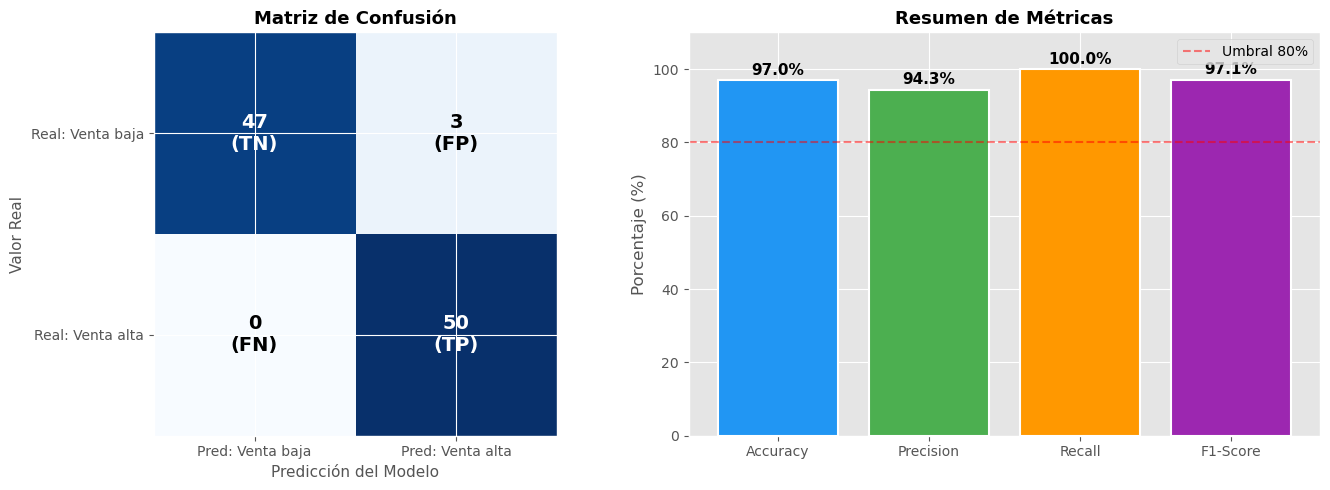


📋 Reporte completo:
              precision    recall  f1-score   support

  Venta baja       1.00      0.94      0.97        50
  Venta alta       0.94      1.00      0.97        50

    accuracy                           0.97       100
   macro avg       0.97      0.97      0.97       100
weighted avg       0.97      0.97      0.97       100



In [17]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
axes[0].imshow(cm, interpolation='nearest', cmap='Blues')
axes[0].set_title('Matriz de Confusión', fontsize=13, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Pred: Venta baja', 'Pred: Venta alta'])
axes[0].set_yticklabels(['Real: Venta baja', 'Real: Venta alta'])
axes[0].set_ylabel('Valor Real', fontsize=11)
axes[0].set_xlabel('Predicción del Modelo', fontsize=11)

etiquetas = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, f'{cm[i, j]}\n({etiquetas[i][j]})',
                     ha='center', va='center', fontsize=14, fontweight='bold',
                     color='white' if cm[i, j] > cm.max()/2 else 'black')

# Barras de métricas
metricas_nombres = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores          = [accuracy, precision, recall, f1]
colores_m        = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

bars = axes[1].bar(metricas_nombres, [v*100 for v in valores],
                   color=colores_m, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Porcentaje (%)')
axes[1].set_title('Resumen de Métricas', fontsize=13, fontweight='bold')
axes[1].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='Umbral 80%')
axes[1].legend()

for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print()
print('📋 Reporte completo:')
print(classification_report(y_test, y_pred, target_names=['Venta baja', 'Venta alta']))

---
## 🔄 Paso 8: Comparar Algoritmos

Probamos más de un modelo para identificar cuál se adapta mejor a los datos validados y ofrece más valor para la operación de la tienda.

- Regresión Logística
- Árbol de Decisión
- Random Forest

La comparación se hará con las métricas del conjunto de prueba, no con los datos de entrenamiento, porque queremos medir capacidad de apoyo real al negocio.

📊 COMPARACIÓN DE ALGORITMOS
             Modelo Accuracy Precision Recall F1-Score
  Árbol de Decisión    0.990     0.980  1.000    0.990
Regresión Logística    0.970     0.943  1.000    0.971
      Random Forest    0.940     0.958  0.920    0.939


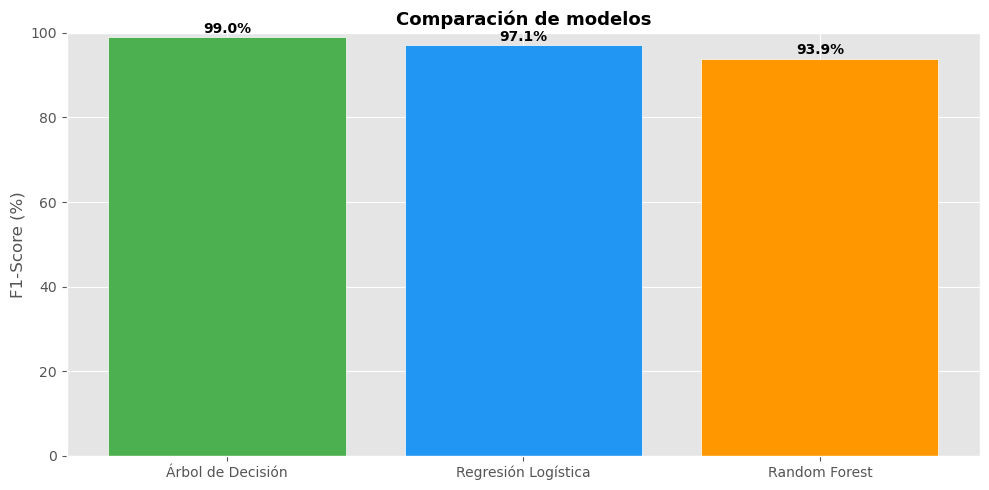

🏆 Mejor modelo: Árbol de Decisión

📋 Reporte del mejor modelo:
              precision    recall  f1-score   support

  Venta baja       1.00      0.98      0.99        50
  Venta alta       0.98      1.00      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



In [ ]:
comparacion = resultados_df.copy().sort_values('F1-Score', ascending=False)

print('📊 COMPARACIÓN DE ALGORITMOS')
print('=' * 72)
print(comparacion.to_string(index=False, formatters={
    'Accuracy': '{:.3f}'.format,
    'Precision': '{:.3f}'.format,
    'Recall': '{:.3f}'.format,
    'F1-Score': '{:.3f}'.format,
}))
print('=' * 72)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(comparacion['Modelo'], comparacion['F1-Score'] * 100, color=['#4CAF50', '#2196F3', '#FF9800'], edgecolor='white')
ax.set_ylim(0, 100)
ax.set_ylabel('F1-Score (%)')
ax.set_title('Comparación de modelos', fontsize=13, fontweight='bold')
for index, value in enumerate(comparacion['F1-Score'] * 100):
    ax.text(index, value + 1, f'{value:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

mejor_nombre = comparacion.iloc[0]['Modelo']
print(f'🏆 Mejor modelo: {mejor_nombre}')
print()
print('📋 Reporte del mejor modelo:')
print(classification_report(y_test, predicciones[mejor_nombre], target_names=['Venta baja', 'Venta alta'], zero_division=0))

¿Qué nos dice esto?
La comparación permite ver si un algoritmo captura mejor la relación entre producto, precio, ciudad y cantidad. Si uno mejora en F1-Score y Recall, suele ser una mejor opción para este caso.

En una demo como esta, lo importante no es quedarse con el primer modelo, sino comprobar si otro algoritmo generaliza mejor sobre el CSV validado y aporta una señal más útil para decisiones comerciales.

---
## 💡 Paso 9: Reflexión — ¿Qué aprendimos?

### ✅ Flujo completo recorrido:

| Paso | Qué hicimos |
|---|---|
| 1 | Cargamos el CSV validado generado por el ETL |
| 2 | Exploramos la distribución de precios, cantidades, productos y ciudades |
| 3 | Creamos una etiqueta binaria `venta_alta` para identificar tickets de mayor valor |
| 4 | Dividimos 80% entrenamiento / 20% prueba con estratificación |
| 5 | Construimos pipelines de preprocesamiento y modelos con scikit-learn |
| 6 | Entrenamos Regresión Logística, Árbol de Decisión y Random Forest |
| 7 | Evaluamos con accuracy, precision, recall, F1 y matriz de confusión |
| 8 | Comparamos el desempeño de varios algoritmos para uso comercial |

### 🔧 Posibles mejoras para seguir iterando:
- Probar ajuste de hiperparámetros con `GridSearchCV`
- Manejar otra variable objetivo de negocio si el CSV la incorpora
- Agregar más variables temporales a partir de `fecha`
- Probar otros algoritmos como `KNeighborsClassifier` o `GradientBoostingClassifier`

---

> 📌 **Conclusión:** con los datos validados del ETL ya es posible construir una demo real de entrenamiento supervisado y comparar modelos de scikit-learn de forma ordenada para apoyar decisiones de una tienda de este tipo.